<div style="background:linear-gradient(135deg,#14b8a6 0%,#6366f1 100%);color:#ffffff;padding:26px 30px;border-radius:16px;font-family:'Segoe UI',Arial,sans-serif;">
  <div style="letter-spacing:.18em;font-size:12px;text-transform:uppercase;opacity:.85;">DS Elective 4 &nbsp;•&nbsp; Deep Learning</div>
  <div style="font-size:30px;font-weight:700;margin:6px 0 2px;">Laboratory Task 2</div>
  <div style="font-size:18px;opacity:.95;">Forward Pass and Error</div>
  <div style="font-size:13px;opacity:.8;margin-top:10px;">Single forward pass of a 3-2-1 neural network with ReLU activation</div>
</div>

**Name:** Edrian C. Jugan

# Task 2: Forward Pass and Error

## 📌 Problem Statement

> **Instruction:** Perform a single forward pass and compute for the error.

**Given**

| Item | Value |
|---|---|
| Input | $x = \begin{bmatrix}1\\0\\1\end{bmatrix}$ |
| Target output | $y = [1]$ |
| Activation | $f = \max(0, Z_n)$ (ReLU) |
| Hidden unit weights | $w_{11}=0.2,\; w_{12}=-0.3,\; w_{13}=0.4,\; w_{14}=0.1,\; w_{15}=-0.5,\; w_{16}=0.2$ |
| Output unit weights | $w_{21}=-0.3,\; w_{22}=-0.2$ |
| Biases | $\theta_1=-0.4,\; \theta_2=0.2,\; \theta_3=0.1$ |

$$
W_{hidden}=\begin{bmatrix} w_{11}=0.2 & w_{12}=-0.3\\ w_{13}=0.4 & w_{14}=0.1\\ w_{15}=-0.5 & w_{16}=0.2\end{bmatrix},\qquad
W_{output}=\begin{bmatrix} w_{21}=-0.3\\ w_{22}=-0.2\end{bmatrix}
$$

## 🧠 The Plan

The network has **3 inputs → 2 hidden units → 1 output**. Column 1 of the hidden weight matrix feeds $H_1$ and column 2 feeds $H_2$.

| Step | Formula |
|---|---|
| 1. Hidden weighted sums | $Z_1 = w_{11}x_1 + w_{13}x_2 + w_{15}x_3 + \theta_1$ and $Z_2 = w_{12}x_1 + w_{14}x_2 + w_{16}x_3 + \theta_2$ |
| 2. Hidden activations | $H_1 = \max(0, Z_1)$ and $H_2 = \max(0, Z_2)$ |
| 3. Output | $Z_3 = w_{21}H_1 + w_{22}H_2 + \theta_3$ and $\hat{y} = \max(0, Z_3)$ |
| 4. Error | $\delta = \hat{y} - y$, squared error $=(y-\hat{y})^2$, loss $E=\tfrac{1}{2}(\hat{y}-y)^2$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# consistent look for every plot in this notebook
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "font.size": 11,
})
TEAL, INDIGO, RED, ORANGE, GREY = "#14b8a6", "#6366f1", "#ef4444", "#f97316", "#94a3b8"

## 🔧 Setup

In [2]:
# input and target
x = np.array([1, 0, 1])
y = np.array([1])

# hidden unit weights (3 inputs x 2 hidden units)
W_h = np.array([[ 0.2, -0.3],    # w11, w12
                [ 0.4,  0.1],    # w13, w14
                [-0.5,  0.2]])   # w15, w16

# output unit weights (2 hidden units x 1 output)
W_o = np.array([[-0.3],          # w21
                [-0.2]])         # w22

# biases: theta1, theta2 (hidden layer) and theta3 (output layer)
theta = np.array([-0.4, 0.2, 0.1])

# activation function f = max(0, Z)
def relu(z):
    return np.maximum(0, z)

## Step 1️⃣ Weighted sums of the hidden layer

$$Z_1 = (0.2)(1) + (0.4)(0) + (-0.5)(1) + (-0.4) = \mathbf{-0.7}$$
$$Z_2 = (-0.3)(1) + (0.1)(0) + (0.2)(1) + (0.2) = \mathbf{0.1}$$

In [3]:
# term by term, exactly like the formulas
Z1 = (0.2 * x[0]) + (0.4 * x[1]) + (-0.5 * x[2]) + theta[0]
Z2 = (-0.3 * x[0]) + (0.1 * x[1]) + (0.2 * x[2]) + theta[1]
print(f"Z1 = {Z1:.4f}")
print(f"Z2 = {Z2:.4f}")

# the same thing using matrix multiplication
Z_h = x @ W_h + theta[:2]
print("\nMatrix form  ->  Z_h =", np.round(Z_h, 4))

Z1 = -0.7000
Z2 = 0.1000

Matrix form  ->  Z_h = [-0.7  0.1]


## Step 2️⃣ Hidden layer activations (ReLU)

$$H_1 = \max(0, -0.7) = \mathbf{0}\qquad H_2 = \max(0, 0.1) = \mathbf{0.1}$$

> 💡 Since $Z_1$ is negative, ReLU switches the first hidden unit **off** for this input.

In [4]:
H = relu(Z_h)
print(f"H1 = {H[0]:.4f}")
print(f"H2 = {H[1]:.4f}")

H1 = 0.0000
H2 = 0.1000


## Step 3️⃣ Output layer

$$Z_3 = (-0.3)(0) + (-0.2)(0.1) + 0.1 = \mathbf{0.08}$$
$$\hat{y} = \max(0, 0.08) = \mathbf{0.08}$$

In [5]:
Z3 = (W_o[0, 0] * H[0]) + (W_o[1, 0] * H[1]) + theta[2]
y_hat = relu(Z3)
print(f"Z3    = {Z3:.4f}")
print(f"y_hat = {y_hat:.4f}")

Z3    = 0.0800
y_hat = 0.0800


## Step 4️⃣ Compute the error

$$\delta = \hat{y} - y = 0.08 - 1 = \mathbf{-0.92}$$
$$\text{Squared error} = (1 - 0.08)^2 = \mathbf{0.8464}\qquad E = \tfrac{1}{2}(0.8464) = \mathbf{0.4232}$$

In [6]:
error = y_hat - y[0]
squared_error = (y[0] - y_hat) ** 2
loss = 0.5 * squared_error

print("+---------------------------------+------------+")
print("| Quantity                        |      Value |")
print("+---------------------------------+------------+")
print(f"| Actual output (y)               | {y[0]:>10.4f} |")
print(f"| Predicted output (y_hat)        | {y_hat:>10.4f} |")
print(f"| Error (y_hat - y)               | {error:>10.4f} |")
print(f"| Squared error                   | {squared_error:>10.4f} |")
print(f"| Loss E = 1/2 * squared error    | {loss:>10.4f} |")
print("+---------------------------------+------------+")

+---------------------------------+------------+
| Quantity                        |      Value |
+---------------------------------+------------+
| Actual output (y)               |     1.0000 |
| Predicted output (y_hat)        |     0.0800 |
| Error (y_hat - y)               |    -0.9200 |
| Squared error                   |     0.8464 |
| Loss E = 1/2 * squared error    |     0.4232 |
+---------------------------------+------------+


## 🎨 Visualizing the forward pass
Blue-green lines are positive weights, red lines are negative weights (thicker = larger). The grey node is the ReLU unit that was switched off.

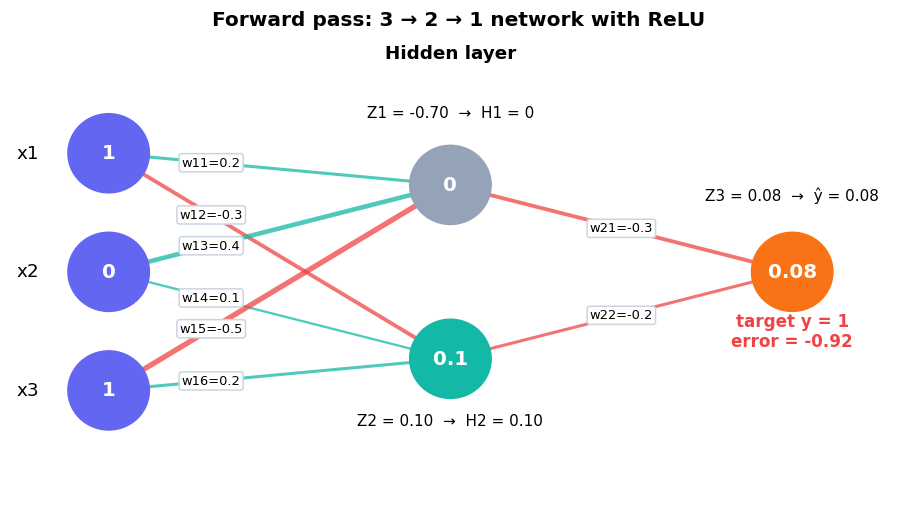

In [7]:
from matplotlib.patches import Circle

def draw_network():
    fig, ax = plt.subplots(figsize=(10.5, 5.6))
    ax.set_xlim(0, 11); ax.set_ylim(0.2, 6.2); ax.axis("off"); ax.grid(False)
    pos = {"x1": (1.2, 4.7), "x2": (1.2, 3.2), "x3": (1.2, 1.7),
           "h1": (5.4, 4.3), "h2": (5.4, 2.1), "o": (9.6, 3.2)}
    edges = [("x1", "h1", 0.2, .30), ("x1", "h2", -0.3, .30), ("x2", "h1", 0.4, .30),
             ("x2", "h2", 0.1, .30), ("x3", "h1", -0.5, .30), ("x3", "h2", 0.2, .30),
             ("h1", "o", -0.3, .50), ("h2", "o", -0.2, .50)]
    names = {("x1","h1"): "w11", ("x1","h2"): "w12", ("x2","h1"): "w13", ("x2","h2"): "w14",
             ("x3","h1"): "w15", ("x3","h2"): "w16", ("h1","o"): "w21", ("h2","o"): "w22"}
    for a, b, w, t in edges:
        (x0, y0), (x1_, y1) = pos[a], pos[b]
        ax.plot([x0, x1_], [y0, y1], color=TEAL if w > 0 else RED, lw=1 + 5 * abs(w), alpha=.75, zorder=1)
        ax.text(x0 + t * (x1_ - x0), y0 + t * (y1 - y0), f"{names[(a, b)]}={w}", fontsize=8.5, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#cbd5e1"), zorder=3)
    vals = {"x1": x[0], "x2": x[1], "x3": x[2], "h1": H[0], "h2": H[1], "o": y_hat}
    cols = {"x1": INDIGO, "x2": INDIGO, "x3": INDIGO, "h1": GREY, "h2": TEAL, "o": ORANGE}
    for k, (px, py) in pos.items():
        ax.add_patch(Circle((px, py), 0.5, color=cols[k], zorder=4))
        ax.text(px, py, f"{vals[k]:g}", color="white", ha="center", va="center", fontsize=13, fontweight="bold", zorder=5)
    for k, lab in [("x1", "x1"), ("x2", "x2"), ("x3", "x3")]:
        ax.text(pos[k][0] - 0.85, pos[k][1], lab, ha="right", va="center", fontsize=12)
    ax.text(5.4, 5.9, "Hidden layer", ha="center", fontsize=12, fontweight="bold")
    ax.text(pos["h1"][0], pos["h1"][1] + 0.85, f"Z1 = {Z_h[0]:.2f}  →  H1 = {H[0]:.0f}", ha="center", fontsize=10)
    ax.text(pos["h2"][0], pos["h2"][1] - 0.85, f"Z2 = {Z_h[1]:.2f}  →  H2 = {H[1]:.2f}", ha="center", fontsize=10)
    ax.text(pos["o"][0], pos["o"][1] + 0.9, f"Z3 = {Z3:.2f}  →  ŷ = {y_hat:.2f}", ha="center", fontsize=10)
    ax.text(pos["o"][0], pos["o"][1] - 0.95, f"target y = {y[0]}\nerror = {error:.2f}", ha="center", fontsize=11, color=RED, fontweight="bold")
    ax.set_title("Forward pass: 3 → 2 → 1 network with ReLU")
    plt.show()

draw_network()

## 🔍 Exact verification (no rounding)

Floating point numbers can hide tiny rounding errors, so here is the same forward pass done with exact fractions.

In [8]:
from fractions import Fraction as F

x_f  = [F(1), F(0), F(1)]
Wh_f = [[F('0.2'), F('-0.3')], [F('0.4'), F('0.1')], [F('-0.5'), F('0.2')]]
Wo_f = [F('-0.3'), F('-0.2')]
th_f = [F('-0.4'), F('0.2'), F('0.1')]
relu_f = lambda z: max(F(0), z)

Z_f  = [sum(x_f[i] * Wh_f[i][j] for i in range(3)) + th_f[j] for j in range(2)]
H_f  = [relu_f(z) for z in Z_f]
Z3_f = sum(H_f[j] * Wo_f[j] for j in range(2)) + th_f[2]
yh_f = relu_f(Z3_f)
err_f = yh_f - 1

for name, v in [("Z1", Z_f[0]), ("Z2", Z_f[1]), ("H1", H_f[0]), ("H2", H_f[1]),
                ("Z3", Z3_f), ("y_hat", yh_f), ("error", err_f), ("squared error", err_f**2), ("loss", err_f**2 / 2)]:
    print(f"{name:<14} = {str(v):>8}   = {float(v):.4f}")

Z1             =    -7/10   = -0.7000
Z2             =     1/10   = 0.1000
H1             =        0   = 0.0000
H2             =     1/10   = 0.1000
Z3             =     2/25   = 0.0800
y_hat          =     2/25   = 0.0800
error          =   -23/25   = -0.9200
squared error  =  529/625   = 0.8464
loss           = 529/1250   = 0.4232


## ✅ Final Answer

| Quantity | Value |
|---|---|
| $Z_1$ | $-0.7$ |
| $H_1 = f(Z_1)$ | $0$ |
| $Z_2$ | $0.1$ |
| $H_2 = f(Z_2)$ | $0.1$ |
| $Z_3$ | $0.08$ |
| **Predicted output** $\hat{y} = f(Z_3)$ | **0.08** |
| **Error** $\hat{y} - y$ | **−0.92** |
| Squared error $(y-\hat{y})^2$ | 0.8464 |
| Loss $\tfrac12(y-\hat{y})^2$ | 0.4232 |

The network predicts $0.08$ while the target is $1$, so it is under-predicting by $0.92$. This is expected with the starting weights, and it is exactly what backpropagation (Task 3) will start correcting.